In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [56]:
# Helper function to display images
def display_images(images, titles, cmap='gray'):
    plt.figure(figsize=(12, 4))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(img, cmap=cmap)
        plt.title(title)
        plt.axis('off')
    plt.show()

### Read `CoffeeBeans.tif` and threshold it

In [8]:
img = cv2.imread('CoffeeBeans.tif')
img.shape
print("Image shape:", img.shape, "min/max:", img.min(), img.max())

Image shape: (296, 301, 3) min/max: 0 231


In [26]:
# Convert to grayscale (I was getting the error "'src_type' is 64 (CV_8UC3)")
if img.ndim == 3:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [28]:
# Convert to 8-bit before applying Otsu

img_8bit = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8) if (img.dtype != np.uint8) else img

# if img.dtype != np.uint8:
#     img_8bit = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

In [31]:
# Otsu with 0 threshold
threshold_value, binary = cv2.threshold(
    img_8bit, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
print("Otsu threshold: ", threshold_value)
print("Binary: ", binary)

Otsu threshold:  71.0
Binary:  [[  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]
 ...
 [  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]]


In [32]:
if np.mean(binary) > 127:
    True

Text(0.5, 1.0, 'Original Image')

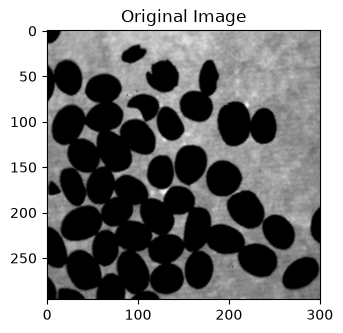

In [43]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img_8bit, cmap='gray')
plt.title("Original Image")

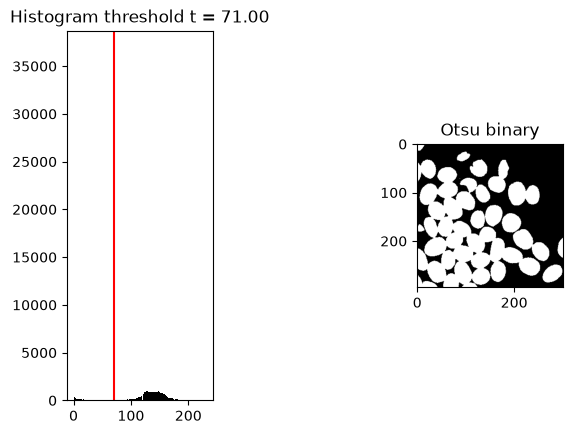

In [55]:
plt.subplot(1,3, 1)
plt.hist(img_8bit.ravel(), bins=256, color='k')
plt.title('Histogram threshold t = {:.2f}'.format(threshold_value))
plt.axvline(threshold_value, color='r')

t, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Beans should be WHITE (foreground). If they're black, invert.
if np.mean(binary) > 127:
    binary = cv2.bitwise_not(binary)

plt.subplot(1,3,3);
plt.imshow(binary, cmap='gray'); 
plt.title("Otsu binary"); 


 #### Segment and label each coffee bean

Here is my approach -
```text
Raw image
   ↓
1. Grayscale + Otsu (binary mask) ➡ done above
   ↓
2. Morphological cleanup (remove specks, fill holes)
   ↓
3. Separate touching beans:
      Distance transform → local maxima → watershed
   ↓
4. Label each bean (connected components)
   ↓
5. Filter tiny regions, measure area/centroid, overlay
```

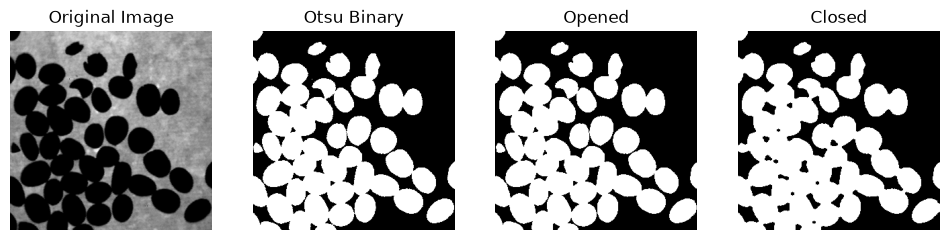

In [60]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

display_images([img_8bit, binary, opened, closed],
               ["Original Image", "Otsu Binary", "Opened", "Closed"])

- Distance transform — for every foreground pixel, distance to nearest background pixel. The center of a bean has a large value; the boundary near where two beans touch has a small value.

- Find local maxima of the distance map → these are the bean centers (candidate seeds).

- Markers = label each seed with a unique integer, background as 0.

- Watershed floods from the seeds and carves boundaries where floods meet.

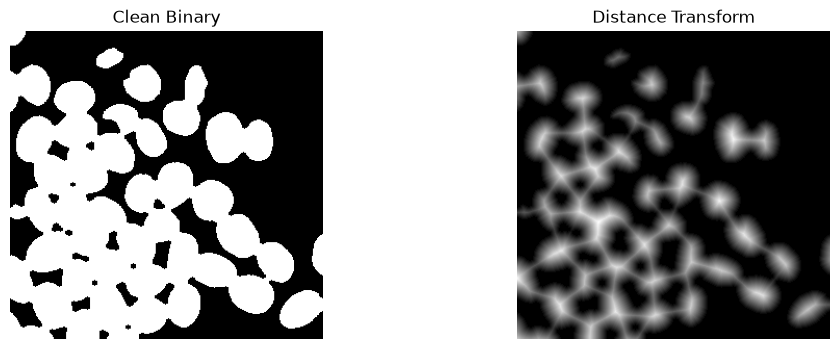

In [62]:
# Distance transform
dist_transform = cv2.distanceTransform(closed, cv2.DIST_L2, 5)
dist_transform = cv2.normalize(
    dist_transform, None, 0, 1.0, cv2.NORM_MINMAX).astype(np.float32)
display_images([closed, dist_transform], ["Clean Binary", "Distance Transform"])


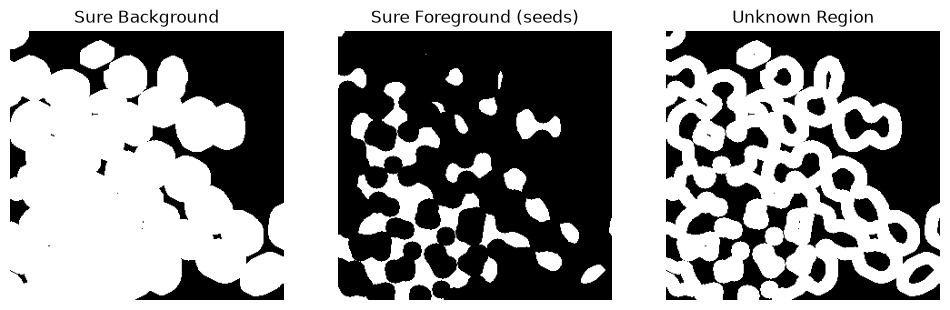

In [66]:
# Threshold the distance transform to get the sure foreground, get the blobs
_, sure_fg = cv2.threshold(dist_transform, 0.4 * dist_transform.max(), 255, 0)
sure_fg = sure_fg.astype(np.uint8)

# Background
sure_bg = cv2.dilate(closed, kernel, iterations=3)

# Unknown region between foreground and background
unknown = cv2.subtract(sure_bg, sure_fg)

display_images([sure_bg, sure_fg, unknown], ["Sure Background", "Sure Foreground (seeds)", "Unknown Region"])

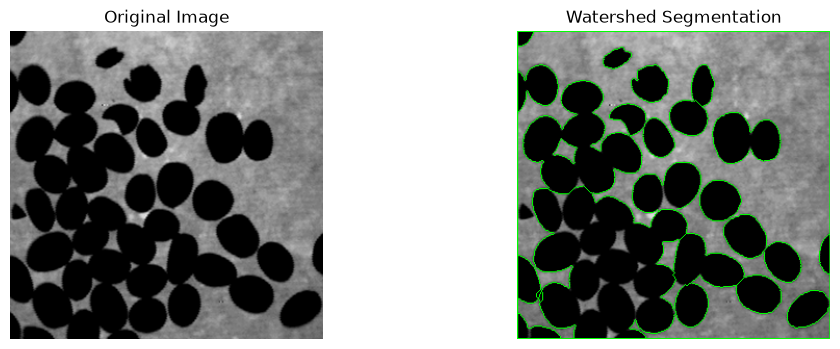

In [ ]:
# Label each seeds 
n_seeds, markers = cv2.connectedComponents(sure_fg)

# Watershed requires markers to be 1-based, so add 1 to all labels, unknown region = 0
markers = markers + 1
markers[unknown == 255] = 0

# Watershed needs a 3-channel image as input (it operates on color gradients)
img_bgr = cv2.cvtColor(img_8bit, cv2.COLOR_GRAY2BGR)
markers = cv2.watershed(img_bgr, markers)

# Mark boundaries in green
overlay = img_bgr.copy()
overlay[markers == -1] = (0,255,0)

display_images([img_bgr, overlay], ["Original Image", "Watershed Segmentation"])

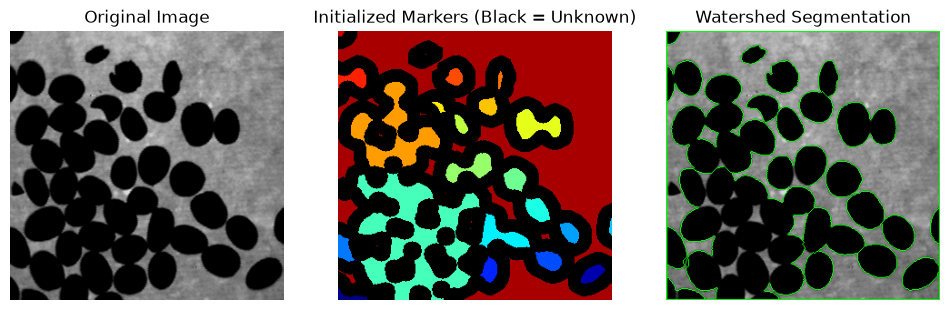

In [76]:
# To visualize in color 
# Label each seed 
n_seeds, markersColored = cv2.connectedComponents(sure_fg)

# Watershed requires markers to be 1-based, so add 1 to all labels, unknown region = 0
markersColored = markersColored + 1
markersColored[unknown == 255] = 0

# 1. Normalize the markers to a 0-255 range so they are visible
# We find the max marker value to scale everything properly
max_marker = np.max(markersColored) if np.max(markersColored) > 0 else 1
visual_markers = (markersColored * (255 / max_marker)).astype(np.uint8)

# 2. Apply a color map 
initial_markers_color = cv2.applyColorMap(visual_markers, cv2.COLORMAP_JET)

# 3. Explicitly force the unknown '0' regions to be pure black so they stand out
initial_markers_color[markersColored == 0] = (0, 0, 0)

# Watershed needs a 3-channel image as input
img_bgr = cv2.cvtColor(img_8bit, cv2.COLOR_GRAY2BGR)
markers = cv2.watershed(img_bgr, markers)

# Mark boundaries in green
overlay = img_bgr.copy()
overlay[markers == -1] = (0,255,0)

# Include your new verification image in the display list!
display_images(
    [img_bgr, initial_markers_color, overlay], 
    ["Original Image", "Initialized Markers (Black = Unknown)", "Watershed Segmentation"]
)
